<a href="https://colab.research.google.com/github/prasa129/Econometrics/blob/main/Vectorized_BS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vectorized OLS Standard Error Bootstrapping

Ram Prasad

09-07-2025

The basic bootstrap structure is to generate B bootstrap replicates of the OLS estimator:

$$
\hat{\beta}^{*(b)} = (X_{b}^{T}X_{b})^{-1}X_{b}^{T}y_{b}, \text{ }b=1...B
$$

Approaches:

1. Pair BS: Each pair $(X_{b}, y_{b})$ is a resampled dataset of size $n$.

2. Residual BS: Fix $X$, resample residuals from original regression and form $y_{b} = X \hat{\beta} + e_{b}$.

Procedurally, for each $b$, construct a dataset, run OLS, retain $\hat{\beta}^{*(b)}$. Generally this requires $B$ for loops, which is computationally expensive. I outline alternatives for each to accelerate computation.

$\textbf{Pair BS}$: Stack bootstrapped design matrices into 3D tensor of shape $(B,n,p)$. The bootstrapped samples are pairs:

$$X_{b} \in \mathcal{R}^{n \times p}, \text{ }y_{b} \in \mathcal{R}^{n}$$

which can be stacked as a tensor and matrix, respectively:

\begin{align*}
X_{b} →& X^{*} \in \mathcal{R}^{B \times n \times p} \\
y_{b} →& y^{*} \in \mathcal{R}^{B \times n} \\
\end{align*}

Gram matrices and RHS product can now be computed in parallel. Introduce notation to be used in the code:

\begin{align*}
\text{XtX}[b] &\equiv X_{b}'X_{b}, \text{ XtX} \in \mathcal{R}^{B \times p \times p}\\
\text{Xty}[b] &\equiv X_{b}'y_{b}, \text{ Xty} \in \mathcal{R}^{B \times p}\\
\end{align*}

and solved in batches (if needed, owing to memory constraints):

$$
\hat{\beta}^{*(b)} = \text{solve}(\text{XtX}[b], \text{Xty}[b])
$$

This approach eliminates Python overhead associated with for loops, but won't be a massive speed up.

$\textbf{Residual BS}$: Use a QR decomposition. $X$ is a $n \times p$ design matrix, with $Q_{n \times p}$ (orthogonal) $R_{p \times p}$ (upper triangular) decomposition:

\begin{align*}
X &= QR \\
\hat{\beta}_{\text{OLS}} &= (X'X)^{-1}X'y \\
&= (R'Q'QR)^{-1}R'Q'y \\
&= (R'IR)^{-1}R'Q'y \\
&= R^{-1}(R')^{-1}R'Q'y\\
&= R^{-1}Q'y
\end{align*}

Construct $Y^{*}_{n \times B} = [y_{1},...,y_{B}]$ by drawing a $n \times B$ matrix (randomly, with replacement) from residuals $e$ (this is a numpy operation, no for loop required). Now all bootstrapped betas can be obtained with one triangular solve:

\begin{align*}
\hat{y} &= X \hat{\beta}_{\text{OLS}} \\
\hat{y}_{n \times B} &\equiv [\hat{y}, ... , \hat{y}] \\
Y^{*}_{n \times B} &= \hat{y}_{n \times B} + e^{*}_{n \times B} \\
\hat{\beta}_{p \times B} &= R^{-1}_{p \times p}(Q_{n \times p}'Y^{*}_{n \times B}) \\
\end{align*}

The experiment proceeds as follows. Simulate regression data with heteroskedastic noise, bootstrap standard errors using each method (pair and residual) and implementation approach (for loop and vectorized), and time execution. Repeat and generate a distribution of execution times. Finally, examine distributions and test for significant differences in average execution times.

Summary Statistics: Execution Times


,Pair(For),Pair(Vec),Residual(For),Residual(Vec)
count,1000.0000,1000.0000,1000.0000,1000.0000
mean,0.2285,0.1068,0.1824,0.0146
std,0.0502,0.0323,0.0439,0.0105
min,0.1924,0.0865,0.1483,0.0097
25%,0.2023,0.0910,0.1589,0.0103
50%,0.2102,0.0935,0.1670,0.0107
75%,0.2244,0.1012,0.1801,0.0114
max,0.7536,0.3977,0.6844,0.0678



Mann-Whitney U-tests for differences in mean execution time. H0: No difference in distributions of execution time. 


,test stat.,p-val.,Conc.
Pair,994034.0,0.0,Reject H0
Residual,1000000.0,0.0,Reject H0


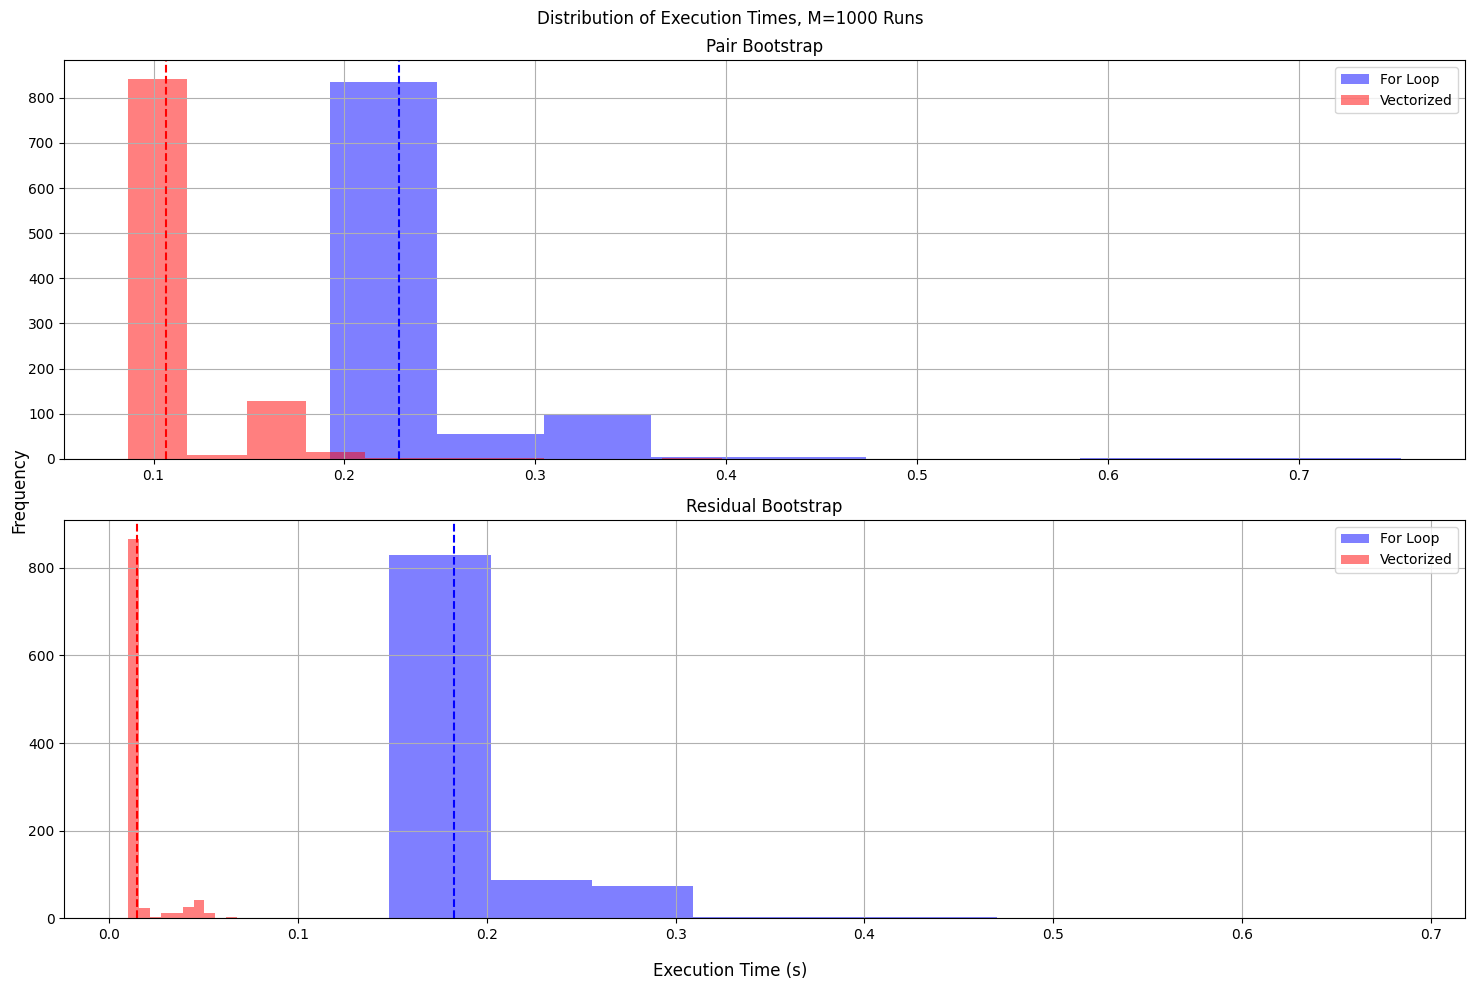

In [1]:
#Standard imports
import numpy as np
import pandas as pd
import scipy as sp
import time
import matplotlib.pyplot as plt


#Utility function to perform least squares
def fit_ols(X, y):
    # OLS via least squares
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

#One function for BS implemented w/for loops.
def bootstrap_ols(X, y, B=2000, method="pairs", random_state=0, ci=(2.5, 97.5)):
    """
    Parameters
    ----------
    X : array-like (n x p) features (intercept will be added if absent)
    y : array-like (n,1) response
    B : int, number of bootstrap replications
    method : {"pairs","residual"}
    random_state : int seed
    ci : tuple, percentile CI bounds

    Returns
    -------
    results : dict with keys:
        beta_hat : OLS coefficients (original sample)
        boot_coefs : (B x p) bootstrap coefficient draws
        se : bootstrap standard errors
        ci : (p x 2) percentile confidence intervals
    """
    #Set seed
    rng = np.random.default_rng(random_state)

    #Set num. obs. and var.
    n, p = X.shape

    #Fit model on original data
    beta_hat = fit_ols(X, y)

    #Compute fitted values
    y_hat = X @ beta_hat

    #Residuals
    resid = y - y_hat

    #Init empty B x p array for bootstrapped beta hat
    boot_coefs = np.empty((B, p))

    #Bootstrap paired X, y
    if method == "pairs":
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            Xb, yb = X[idx], y[idx]
            boot_coefs[b] = fit_ols(Xb, yb).flatten()

    #Bootstrap residuals
    elif method == "residual":
        # Assumes iid (homoskedastic) residuals; center residuals
        e = resid - np.mean(resid)
        for b in range(B):
            eb = rng.choice(e, size=n, replace=True)
            yb = y_hat + eb
            boot_coefs[b] = fit_ols(X, yb).flatten()

    #Raise error if unspecified method passed in
    else:
        raise ValueError("BS method must be one of {'pairs','residual'}.")

    # Standard errors and percentile CIs
    se = boot_coefs.std(axis=0, ddof=1)
    ci = np.percentile(boot_coefs, q=list(ci), axis=0).T

    #Return dictionary with BS results (original beta hat, array of BS est. SE, CI)
    return {"beta_hat": beta_hat,
            "boot_coefs": boot_coefs,
            "se": se,
            "ci": ci
            }

#Vectorized implementation of residual bootstrap (no for loop)
def residual_bootstrap_vectorized(X, y, B=2000, method="residual", random_state=0):
    """
    Parameters
    ----------
    X : array-like (n x p) features
    y : array-like (n,1) response
    B : int, number of bootstrap replications
    method : {"residual","wild"}
    random_state : int seed

    Returns
    -------
    results : dict with keys:
        beta_hat : OLS coefficients (original sample)
        boot_coefs : (B x p) bootstrap coefficient draws
        se : bootstrap standard errors
        ci : (p x 2) percentile confidence intervals

    Use QR decomposition to speed up computation.
    """

    #Check for valid choice of BS method
    if method != "residual":
        raise ValueError("BS method must be {'residual'}.")

    #Set random seed
    rng = np.random.default_rng(random_state)

    #Store number of obs. and variables
    n, p = X.shape

    #Perform OLS once using QR decomp. Q is n x p, R is p x p.
    Q, R = np.linalg.qr(X, mode="reduced")
    beta_hat = np.linalg.solve(R, Q.T @ y)

    #Computed fitted values and residuals. y_hat is n x 1.
    y_hat = X @ beta_hat
    resid = y - y_hat

    #Center residuals
    e = resid - resid.mean()

    #Draw B vectors, dim. n x 1, from residuals (randomly, with replacement)
    Eb = rng.choice(e.flatten(), size=(n, B), replace=True)

    #Construct Yb, which is n x B
    Yb = np.full((n, B), y_hat) + Eb

    """
    Solve for all BS Betas simultaneously.
    Beta_b = R^{-1} Q^T Yb, where Q^T Yb is (p × B).
    One loop-free solve.
    """
    QTYb = Q.T @ Yb
    Betas = np.linalg.solve(R, QTYb)

    #Compute BS SE using std. dev. of bootstrapped betas
    se = Betas.std(axis=1, ddof=1)

    #Compute CI
    lo, hi = np.percentile(Betas, [2.5, 97.5], axis=1)

    #Return dictionary of results
    results = {"beta_hat": beta_hat, "boot_coefs": Betas, "se": se, "ci": np.c_[lo, hi]}
    return results

def bootstrap_pairs_batched(X, y, B=2000, random_state=0, chunk=None):
    """
    Parameters
    ----------
    X : array-like (n x p) features
    y : array-like (n,1) response
    B : int, number of bootstrap replications
    random_state : int seed
    Returns:
    -------
    results : dict with keys:
        beta_hat : OLS coefficients (original sample)
        boot_coefs : (B x p) bootstrap coefficient draws
        se : bootstrap standard errors
        ci : (p x 2) percentile confidence intervals

    Fully vectorized implementation of pair BS over B. If memory is tight, set `chunk` to process in mini-batches.
    """

    #Set random seed, store num. obs. and variables
    rng = np.random.default_rng(random_state)
    n, p = X.shape

    #Batch processing of tensors for einstein summation.
    def run_batch(Bb):

        #Select indices, dimension Bb x n
        idx = rng.integers(0, n, size=(Bb, n))

        #Select BS X and y, dim. (Bb x n x p) and (Bb x n), respectively.
        Xb = X[idx]                                       # (Bb × n × p)
        yb = y.flatten()[idx]                             # (Bb × n)

        #Compute normal equations per bootstrap: (X'X) beta = X'y (batched)
        XtX = np.einsum("bnp,bnq->bpq", Xb, Xb)           # (Bb × p × p)
        Xty = np.einsum("bnp,bn->bp", Xb, yb)             # (Bb × p)

        # Solve (batched): NumPy supports stacked systems
        betas = np.linalg.solve(XtX, Xty[..., None])[..., 0]   # (Bb × p)
        return betas

    #If no chunk size specified
    if chunk is None:

        #Run without batching
        Betas = run_batch(B)

    #Otherwise
    else:
        #Separate into batches of size chunk and estimate
        outs = []
        for s in range(0, B, chunk):

            #estimate on chunk, store returned array of beta hats
            outs.append(run_batch(min(chunk, B - s)))

        #Vertically stack output
        Betas = np.vstack(outs)

    #Store point estimate from full sample
    beta_hat = np.linalg.lstsq(X, y, rcond=None)[0]

    #SE, CIs from BS estimates
    se = Betas.std(axis=0, ddof=1)
    lo, hi = np.percentile(Betas, [2.5, 97.5], axis=0)

    #Return dictionary of results
    return {"beta_hat": beta_hat, "boot_coefs": Betas, "se": se, "ci": np.c_[lo, hi]}

# ------------------ main call ------------------
if __name__ == "__main__":

    """
    Simulate data from pop. model Y = B0 + B1*X1 + B2*X2 + e
    X1 ~ N(0,1), X2 ~ N(0,1)
    Use heteroskedastic random errors.
    e_i ~ N( mu = 0, sigma = 1 + 0.75*|X1_i| )
    n = 500.
    """
    #Set seed for data reproducability
    rng = np.random.default_rng(42)

    #Set sample size and bootstrap size
    n = 500
    B = 2000

    #Draw covariates from N(0,1) distributions
    X1 = rng.normal(size=n)
    X2 = rng.normal(size=n)

    #Draw heteroskedastic random errors
    eps = rng.normal(scale=1 + 0.75 * np.abs(X1)).reshape((n,1))

    #Set true parameter values
    B0, B1, B2 = 1.5, 2.0, -1.0
    Beta = np.array([[B0, B1, B2]]).T

    #Construct design matrix. Prepend column of 1s.
    X = np.c_[np.ones(n), X1, X2]

    #Construct dependent variable
    y = X @ Beta + eps


    """
    Perform experiment. Use each type of bootstrap to compute SE and CI.
    Compare execution time using for loop and vectorized implementation.
    Repeat M times, compute mean and std., display results. T-test to compare.
    """
    #Set number of experiment runs
    M = 1000

    #Per run, call each BS function, retain execution times
    exp_results = []
    for _ in range(M):

      #Bootstrap SE w/pairs (for loop)
      t0 = time.time()
      out_pairs = bootstrap_ols(X, y, B=B, method="pairs", random_state=1)
      t1 = time.time()
      pair_for_loop_time = t1 - t0

      #Bootstrape SE w/pairs (vectorized)
      t0 = time.time()
      out_pairs_vec = bootstrap_pairs_batched(X, y, B=B, random_state=1)
      t1 = time.time()
      pair_vec_time = t1 - t0

      #Bootstrap SE w/residual (for loop)
      t0 = time.time()
      out_resid = bootstrap_ols(X, y, B=B, method="residual", random_state=1)
      t1 = time.time()
      resid_for_loop_time = t1 - t0

      #Bootstrap SE w/residual (vectorized)
      t0 = time.time()
      out_resid_vec = residual_bootstrap_vectorized(X, y, B=B, method="residual", random_state=1)
      t1 = time.time()
      resid_vec_time = t1 - t0

      #Track results
      exp_results.append({"Pair(For)":pair_for_loop_time,
                          "Pair(Vec)":pair_vec_time,
                          "Residual(For)":resid_for_loop_time,
                          "Residual(Vec)":resid_vec_time})

    #Convert to DataFrame, summarize
    exp_results = pd.DataFrame(exp_results)
    print("Summary Statistics: Execution Times")
    display(exp_results.describe().round(4))


    #MWU-test for differences in mean execution time. H0: mean time w/for loop = mean time w/vectorization
    pair_stat, pair_p_val = sp.stats.mannwhitneyu(exp_results["Pair(For)"], exp_results["Pair(Vec)"])
    resid_stat, resid_p_val = sp.stats.mannwhitneyu(exp_results["Residual(For)"], exp_results["Residual(Vec)"])

    #Show stat and p-values in dataframe
    print("\nMann-Whitney U-tests for differences in mean execution time. H0: No difference in distributions of execution time. ")
    tt_df = pd.DataFrame({"Pair": [pair_stat, pair_p_val],
                          "Residual": [resid_stat, resid_p_val]}, index=["test stat.", "p-val."]).T

    #Test at 5% level, display results
    tt_df["Conc."] = np.where(tt_df["p-val."] < 0.05, "Reject H0","Fail to reject H0")
    display(tt_df.round(4))
    print("\n\n")

    #Plot distribution of execution times
    fig, axs = plt.subplots(2, 1, figsize=(15,10))
    for r, method in zip([0,1],["Pair","Residual"]):

      #Histograms of for loop and vectorized execution times
      axs[r].hist(exp_results[f"{method}(For)"], label="For Loop", color="b", alpha=0.5)
      axs[r].hist(exp_results[f"{method}(Vec)"], label="Vectorized", color="r", alpha=0.5)

      #Vertical lines for means
      axs[r].axvline(x=exp_results[f"{method}(For)"].mean(), color="b", linestyle="--")
      axs[r].axvline(x=exp_results[f"{method}(Vec)"].mean(), color="r", linestyle="--")

      #Grid, subtitle, legend
      axs[r].grid()
      axs[r].set_title(f"{method} Bootstrap")
      axs[r].legend()

    #Set plot title and display
    fig.suptitle(f"Distribution of Execution Times, M={M} Runs")
    fig.supylabel("Frequency")
    fig.supxlabel("Execution Time (s)")
    plt.tight_layout()
    plt.show()

The time savings for paired bootstrapping are modest, reducing average computation time from 0.25s to 0.12s. For residual bootstrapping, the gains are tremendous. Average execution time falls from 0.20s to 0.02s on account of eliminating for loops. These results use $p=2$, $n=500$, $B=2000$ replicates, and $M=1000$ experimental runs. Non-parametric Mann-Whitney test confirms there are statistically significant differences in the locations of the execution time distributions.

Check standard errors, CIs, and so forth. Sanity check results against known simulation parameter values.

,Intercept,X1,X2
Coef,1.4759,2.1264,-1.0779
"SE (Pairs, for loop)",0.0743,0.1113,0.0723
"SE (Pairs, vectorized)",0.0743,0.1113,0.0723
"SE (Resid., for loop)",0.0744,0.0792,0.0747
"SE (Resid., vectorized)",0.0768,0.0799,0.0758
CI.L(Pairs),1.3328,1.9041,-1.2192
CI.H(Pairs),1.6192,2.3450,-0.9351
CI.L(Resid.),1.3329,1.9740,-1.2357
CI.H(Resid.),1.6167,2.2787,-0.9365


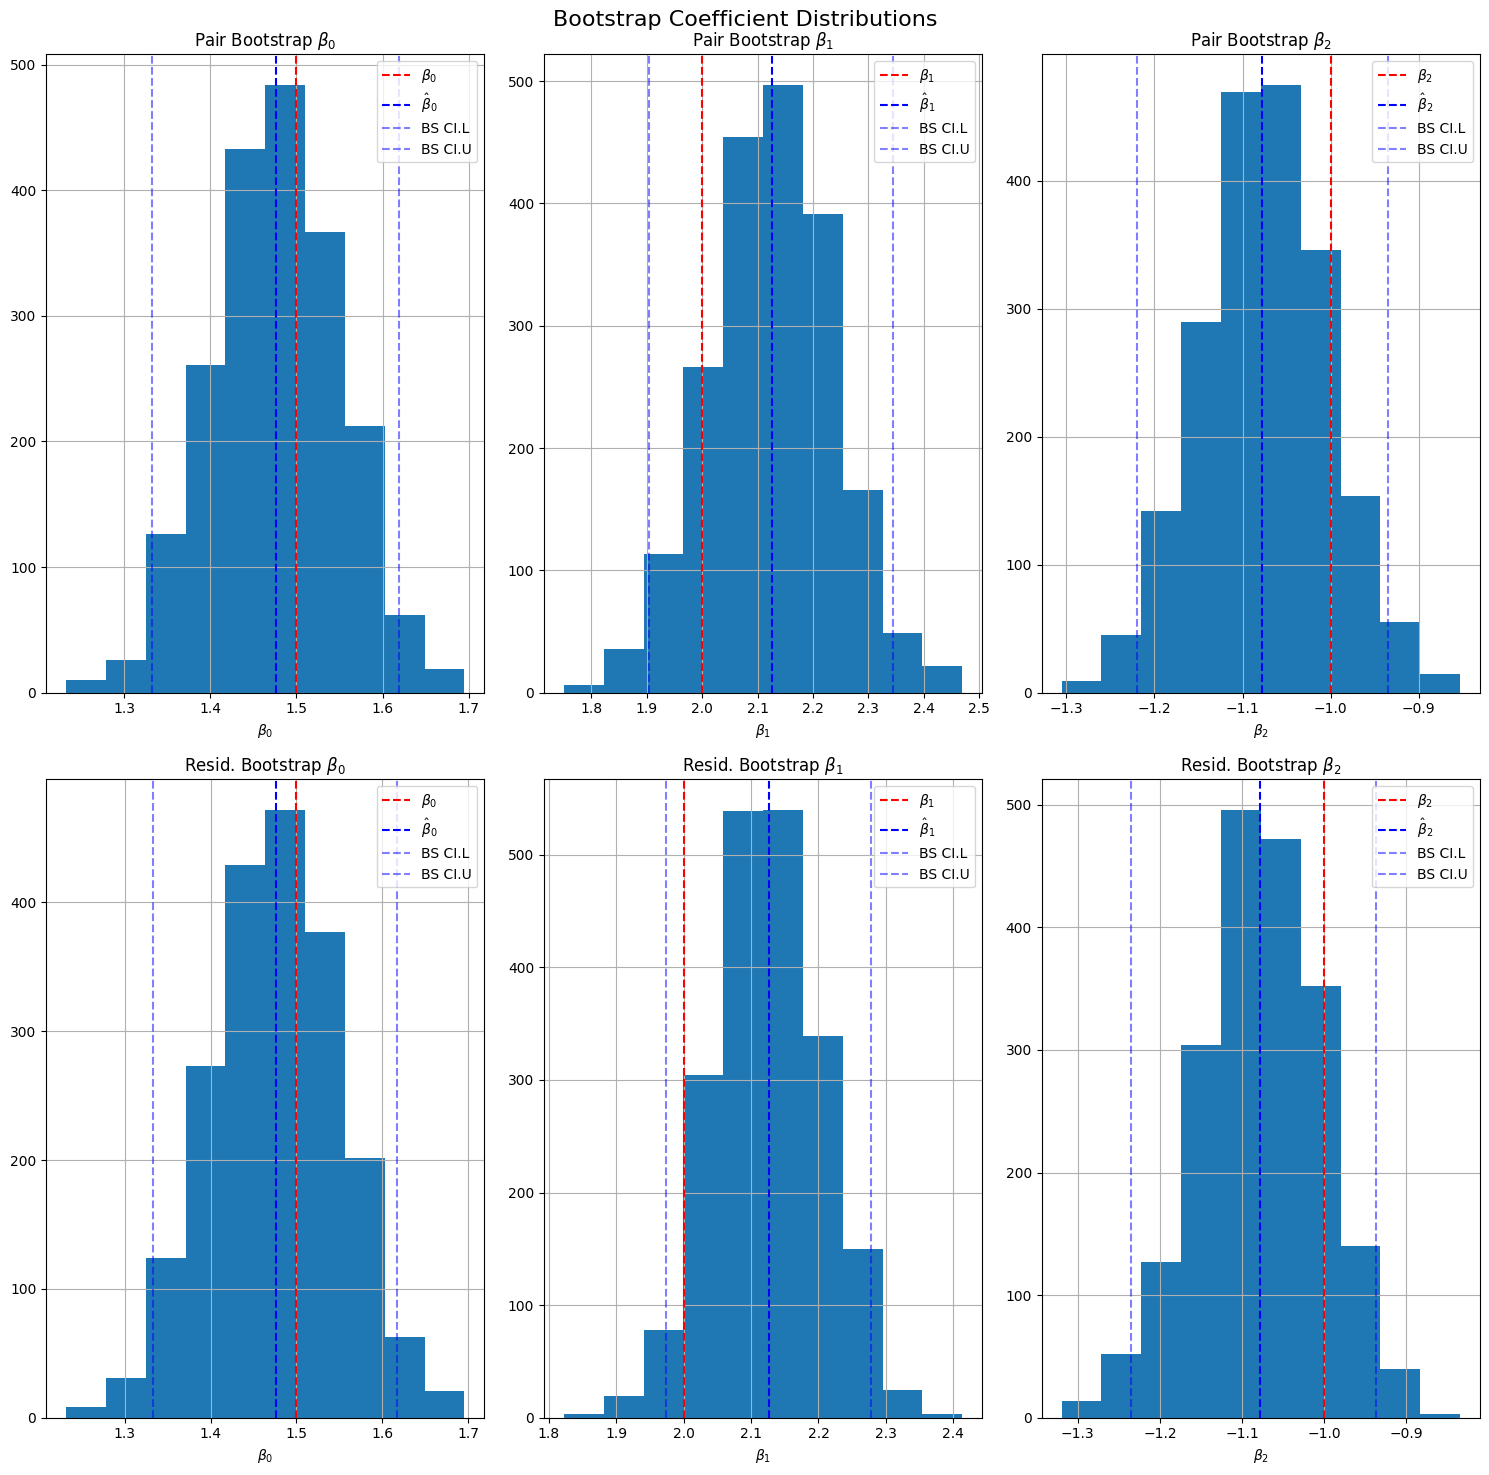

In [2]:
if __name__ == "__main__":
    """
    Show results and plots. Include true parameter values, BS estimates, and CI.
    Compare SEs and CIs for each method and implementation type.
    """
    #Create DF for results
    names = ["Intercept", "X1", "X2"]
    df = pd.DataFrame({

        #Estimated Beta
        "Coef": out_pairs["beta_hat"].flatten(),

        #Pair BS Standard errors (for loop)
        "SE (Pairs, for loop)": out_pairs["se"],

        #Pair BS Standard errors (vectorized)
        "SE (Pairs, vectorized)": out_pairs_vec["se"],

        #Residual BS Standard errors (for loop)
        "SE (Resid., for loop)": out_resid["se"],

        #Residual BS Standard errors (vectorized)
        "SE (Resid., vectorized)": out_resid_vec["se"],

        #Pair BS CI, lower and upper
        "CI.L(Pairs)": out_pairs["ci"][:, 0],
        "CI.H(Pairs)": out_pairs["ci"][:, 1],
        "CI.L(Resid.)": out_resid["ci"][:, 0],
        "CI.H(Resid.)": out_resid["ci"][:, 1],
    }, index=names)

    #Display results
    display(df.round(4).T)

    #2x3 grid for histogram of BS coefficient estimates, CI, true value
    fig, axs = plt.subplots(2, 3, figsize=(15, 15))

    #Each row is a bootstrap type: paired, residual
    for r, result, title in zip([0,1], [out_pairs, out_resid],["Pair","Resid."]):

      #Each column is parameter: B0, B1, B2
      for c, beta, beta_hat in zip([0,1,2], [r"$\beta_{0}$",r"$\beta_{1}$",r"$\beta_{2}$"], [r"$\hat{\beta}_{0}$",r"$\hat{\beta}_{1}$",r"$\hat{\beta}_{2}$"]):

        #Histogram of BS coefficient estimates
        axs[r][c].hist(result['boot_coefs'][:,c])

        #Vertical line to mark true parameter value
        axs[r][c].axvline(x=Beta[c], color='r', linestyle='--', label=beta)

        #Vertical line to mark OLS estimate with original data
        axs[r][c].axvline(x=result['beta_hat'][c], color='b', linestyle='--', label=beta_hat)

        #Vertical lines for CI
        axs[r][c].axvline(x=result['ci'][c,0], color='b', alpha=0.50, linestyle='--', label="BS CI.L")
        axs[r][c].axvline(x=result['ci'][c,1], color='b', alpha=0.50, linestyle='--', label="BS CI.U")

        #Set xlabel, title, grid, and legend
        axs[r][c].set_xlabel(beta)
        axs[r][c].set_title(f"{title} Bootstrap {beta}")
        axs[r][c].grid()
        axs[r][c].legend()

    #Set super title and display
    plt.suptitle("Bootstrap Coefficient Distributions", fontsize=16)
    plt.tight_layout()
    plt.show()


The functions are working as intended. Standard errors are quite similar when using different implementation methods for both bootstrap methods. The 95% bootstrapped CIs contain the true parameter value for all parameters and BS methods.